In [ ]:
#cell 1
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/LeafNet/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/LeafNet/results', exist_ok=True)
print("Drive mounted. Folders created.")

Mounted at /content/drive
Drive mounted. Folders created.


In [ ]:
pip install tensorflow kaggle scikit-learn matplotlib seaborn pillow opencv-python-headless albumentations

In [ ]:
#cell 3
import os

# Paste your credentials directly
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"rupeshbhatta","key":"KGAT_4b7ba8cf36ea09412ddd720497b26bf5"}')

os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download dataset
os.system('kaggle datasets download -d arjuntejaswi/plant-village --unzip -p /content/data')
print("Dataset downloaded.")

Dataset downloaded.


In [ ]:
#cell 4
import os

data_root = '/content/data/PlantVillage'

# List all folders
all_classes = sorted(os.listdir(data_root))
print(f"Total classes in PlantVillage: {len(all_classes)}")
print()

# Filter only potato classes
potato_classes = [c for c in all_classes if 'Potato' in c]
print("Potato classes found:")
for cls in potato_classes:
    path = os.path.join(data_root, cls)
    count = len(os.listdir(path))
    print(f"  {cls}: {count} images")

Total classes in PlantVillage: 15

Potato classes found:
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images


In [ ]:
#cell 5
import shutil, random
random.seed(42)

src_root = '/content/data/PlantVillage'
dst_root = '/content/potato'

# Map class folders to clean names
class_map = {
    'Potato___Early_blight': 'Early_Blight',
    'Potato___Late_blight':  'Late_Blight',
    'Potato___healthy':      'Healthy',
}

# Copy and rename into clean structure
for src_name, dst_name in class_map.items():
    src_path = os.path.join(src_root, src_name)
    dst_path = os.path.join(dst_root, 'all', dst_name)
    if os.path.exists(src_path):
        shutil.copytree(src_path, dst_path)
        print(f"Copied {src_name} → {dst_name}: {len(os.listdir(dst_path))} images")
    else:
        print(f"NOT FOUND: {src_name}")
        print("Available folders:", os.listdir(src_root)[:5])

Copied Potato___Early_blight → Early_Blight: 1000 images
Copied Potato___Late_blight → Late_Blight: 1000 images
Copied Potato___healthy → Healthy: 152 images


In [ ]:
#cell 6
from sklearn.model_selection import train_test_split
import shutil, os, random
random.seed(42)

src_all   = '/content/potato/all'
dst_train = '/content/potato/train'
dst_val   = '/content/potato/val'
dst_test  = '/content/potato/test'

for split in [dst_train, dst_val, dst_test]:
    os.makedirs(split, exist_ok=True)

for cls in os.listdir(src_all):
    cls_path = os.path.join(src_all, cls)
    images   = os.listdir(cls_path)
    random.shuffle(images)

    # Split
    train_imgs, temp   = train_test_split(images, test_size=0.30, random_state=42)
    val_imgs,  test_imgs = train_test_split(temp,  test_size=0.50, random_state=42)

    for split_name, split_imgs in [('train', train_imgs),
                                    ('val',   val_imgs),
                                    ('test',  test_imgs)]:
        split_cls_dir = f'/content/potato/{split_name}/{cls}'
        os.makedirs(split_cls_dir, exist_ok=True)
        for img in split_imgs:
            shutil.copy(os.path.join(cls_path, img),
                        os.path.join(split_cls_dir, img))

    print(f"{cls}: train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

Healthy: train=106, val=23, test=23
Early_Blight: train=700, val=150, test=150
Late_Blight: train=700, val=150, test=150


In [ ]:
#cell 7
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE  = (224, 224)
BATCH     = 32

# Training: augmentation + normalisation
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
)

# Validation and test: normalisation only
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/potato/train',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', seed=42)

val_data = val_test_gen.flow_from_directory(
    '/content/potato/val',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', seed=42, shuffle=False)

test_data = val_test_gen.flow_from_directory(
    '/content/potato/test',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', seed=42, shuffle=False)

print("Class indices:", train_data.class_indices)
print(f"Train: {train_data.samples} | Val: {val_data.samples} | Test: {test_data.samples}")

Found 1506 images belonging to 3 classes.
Found 323 images belonging to 3 classes.
Found 323 images belonging to 3 classes.
Class indices: {'Early_Blight': 0, 'Healthy': 1, 'Late_Blight': 2}
Train: 1506 | Val: 323 | Test: 323


In [ ]:
#cell 8
import numpy as np
import tensorflow as tf
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Random seeds fixed at 42.")

Random seeds fixed at 42.


In [ ]:
#cell 9
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras import layers, models, Model

NUM_CLASSES = 3  # Early_Blight, Late_Blight, Healthy

def build_transfer_model(base_name):
    """Build a transfer learning model with frozen base + custom head."""

    if base_name == 'VGG16':
        base = VGG16(weights='imagenet', include_top=False,
                     input_shape=(224, 224, 3))
    elif base_name == 'ResNet50':
        base = ResNet50(weights='imagenet', include_top=False,
                        input_shape=(224, 224, 3))
    elif base_name == 'MobileNetV2':
        base = MobileNetV2(weights='imagenet', include_top=False,
                           input_shape=(224, 224, 3))

    # Freeze all base layers
    base.trainable = False

    # Custom classification head
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    return model, base


def build_custom_cnn():
    """Build a custom CNN from scratch."""
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                      input_shape=(224, 224, 3)),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ])
    return model

print("Model builder functions ready.")

Model builder functions ready.


In [ ]:
#cell 10
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)

def get_callbacks(model_name):
    save_path = f'/content/drive/MyDrive/LeafNet/models/{model_name}_best.h5'
    return [
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(save_path, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                          patience=3, verbose=1, min_lr=1e-7),
    ]
print("Callbacks ready.")

Callbacks ready.


In [ ]:
#cell 11
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

histories = {}
trained_models = {}

configs = [
    ('VGG16',       'transfer'),
    ('ResNet50',    'transfer'),
    ('MobileNetV2', 'transfer'),
    ('CustomCNN',   'custom'),
]

for model_name, model_type in configs:
    print(f"\n{'='*50}")
    print(f"Processing: {model_name}")
    print(f"{'='*50}")

    # ── Check if already trained and saved to Drive ──
    save_path = f'/content/drive/MyDrive/LeafNet/models/{model_name}_best.h5'
    finetuned_path = f'/content/drive/MyDrive/LeafNet/models/{model_name}_finetuned_best.h5'

    # Use finetuned version if available, otherwise use base trained version
    load_path = finetuned_path if os.path.exists(finetuned_path) else save_path

    if os.path.exists(load_path):
        print(f"Already trained — loading from Drive: {load_path}")
        trained_models[model_name] = load_model(load_path)
        print(f"✓ {model_name} loaded successfully. Skipping training.")
        continue

    # ── Build model ──
    if model_type == 'transfer':
        model, base = build_transfer_model(model_name)
    else:
        model = build_custom_cnn()

    # ── Phase 1: Feature extraction ──
    print(f"\nPhase 1: Feature extraction — {model_name}")
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_data,
        epochs=30,
        validation_data=val_data,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    histories[model_name] = history
    print(f"✓ Phase 1 complete. Model saved to Drive.")

    # ── Phase 2: Fine-tuning (transfer models only) ──
    if model_type == 'transfer':
        print(f"\nPhase 2: Fine-tuning — {model_name}")

        # Reload best weights from Phase 1 before fine-tuning
        model = load_model(save_path)

        # Rebuild base reference for unfreezing
        if model_name == 'VGG16':
            from tensorflow.keras.applications import VGG16
            base = VGG16(weights=None, include_top=False,
                         input_shape=(224, 224, 3))
        elif model_name == 'ResNet50':
            from tensorflow.keras.applications import ResNet50
            base = ResNet50(weights=None, include_top=False,
                            input_shape=(224, 224, 3))
        elif model_name == 'MobileNetV2':
            from tensorflow.keras.applications import MobileNetV2
            base = MobileNetV2(weights=None, include_top=False,
                               input_shape=(224, 224, 3))

        # Unfreeze last 20 layers of the loaded model's base
        # The base layers are all layers except the last 3 (GAP, Dense, Dropout, Output)
        for layer in model.layers[:-4]:
            layer.trainable = False
        for layer in model.layers[-24:-4]:  # unfreeze last 20 base layers
            layer.trainable = True

        model.compile(
            optimizer=Adam(learning_rate=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history_ft = model.fit(
            train_data,
            epochs=20,
            validation_data=val_data,
            callbacks=get_callbacks(f"{model_name}_finetuned"),
            verbose=1
        )
        print(f"✓ Phase 2 fine-tuning complete. Fine-tuned model saved to Drive.")

    trained_models[model_name] = model
    print(f"\n✓ {model_name} fully complete and saved to Drive.")

print("\n" + "="*50)
print("All models ready.")
print("="*50)
print("\nModels in memory:", list(trained_models.keys()))


Processing: VGG16
Already trained — loading from Drive: /content/drive/MyDrive/LeafNet/models/VGG16_finetuned_best.h5


✓ VGG16 loaded successfully. Skipping training.

Processing: ResNet50
Already trained — loading from Drive: /content/drive/MyDrive/LeafNet/models/ResNet50_finetuned_best.h5


✓ ResNet50 loaded successfully. Skipping training.

Processing: MobileNetV2
Already trained — loading from Drive: /content/drive/MyDrive/LeafNet/models/MobileNetV2_finetuned_best.h5


✓ MobileNetV2 loaded successfully. Skipping training.

Processing: CustomCNN
Already trained — loading from Drive: /content/drive/MyDrive/LeafNet/models/CustomCNN_best.h5


✓ CustomCNN loaded successfully. Skipping training.

All models ready.

Models in memory: ['VGG16', 'ResNet50', 'MobileNetV2', 'CustomCNN']


In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
import numpy as np

CLASS_NAMES = list(test_data.class_indices.keys())
results = {}

for model_name, model in trained_models.items():
    print(f"\n{'='*50}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*50}")

    # Reset test data before each evaluation
    test_data.reset()

    # Get predictions
    y_pred_prob = model.predict(test_data, verbose=1)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_data.classes

    # Calculate metrics
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average='macro')
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
    cm     = confusion_matrix(y_true, y_pred)

    # Store results
    results[model_name] = {
        'accuracy': acc,
        'f1': f1,
        'report': report,
        'cm': cm,
        'y_true': y_true,
        'y_pred': y_pred
    }

    # Print results
    print(f"Test Accuracy : {acc*100:.2f}%")
    print(f"Macro F1-Score: {f1:.4f}")
    print()
    print("Classification Report:")
    print(report)
    print("Confusion Matrix:")
    print(cm)

    # Save each model result to Drive
    result_text = f"""{model_name} EVALUATION RESULTS
{'='*40}
Test Accuracy : {acc*100:.2f}%
Macro F1-Score: {f1:.4f}

Classification Report:
{report}

Confusion Matrix:
{cm}
"""
    with open(f'/content/drive/MyDrive/LeafNet/results/{model_name}_results.txt', 'w') as f:
        f.write(result_text)
    print(f"✓ {model_name} results saved to Drive.")

print("\n" + "="*50)
print("ALL MODELS EVALUATED")
print("="*50)

# Print final comparison summary
print("\nFINAL COMPARISON SUMMARY")
print("-"*40)
print(f"{'Model':<15} {'Accuracy':>10} {'Macro F1':>10}")
print("-"*40)
for model_name, res in results.items():
    print(f"{model_name:<15} {res['accuracy']*100:>9.2f}% {res['f1']:>10.4f}")
print("-"*40)

# Identify best model
best_model_name = max(results, key=lambda x: results[x]['f1'])
print(f"\nBest model by Macro F1: {best_model_name} ({results[best_model_name]['f1']:.4f})")


Evaluating: VGG16
11/11 ━━━━━━━━━━━━━━━━━━━━ 129s 12s/step
Test Accuracy : 95.36%
Macro F1-Score: 0.9201

Classification Report:
              precision    recall  f1-score   support

Early_Blight       0.95      1.00      0.97       150
     Healthy       0.90      0.78      0.84        23
 Late_Blight       0.97      0.93      0.95       150

    accuracy                           0.95       323
   macro avg       0.94      0.91      0.92       323
weighted avg       0.95      0.95      0.95       323

Confusion Matrix:
[[150   0   0]
 [  0  18   5]
 [  8   2 140]]
✓ VGG16 results saved to Drive.

Evaluating: ResNet50
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step
Test Accuracy : 82.04%
Macro F1-Score: 0.5674

Classification Report:
              precision    recall  f1-score   support

Early_Blight       0.86      0.88      0.87       150
     Healthy       0.00      0.00      0.00        23
 Late_Blight       0.79      0.89      0.83       150

    accuracy                           0.82 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✓ ResNet50 results saved to Drive.

Evaluating: MobileNetV2
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 974ms/step
Test Accuracy : 99.07%
Macro F1-Score: 0.9873

Classification Report:
              precision    recall  f1-score   support

Early_Blight       0.99      1.00      0.99       150
     Healthy       0.96      1.00      0.98        23
 Late_Blight       1.00      0.98      0.99       150

    accuracy                           0.99       323
   macro avg       0.98      0.99      0.99       323
weighted avg       0.99      0.99      0.99       323

Confusion Matrix:
[[150   0   0]
 [  0  23   0]
 [  2   1 147]]
✓ MobileNetV2 results saved to Drive.

Evaluating: CustomCNN
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 756ms/step
Test Accuracy : 97.52%
Macro F1-Score: 0.9550

Classification Report:
              precision    recall  f1-score   support

Early_Blight       0.99      0.99      0.99       150
     Healthy       0.82      1.00      0.90        23
 Late_Blight       0.99      0.96      0.97     

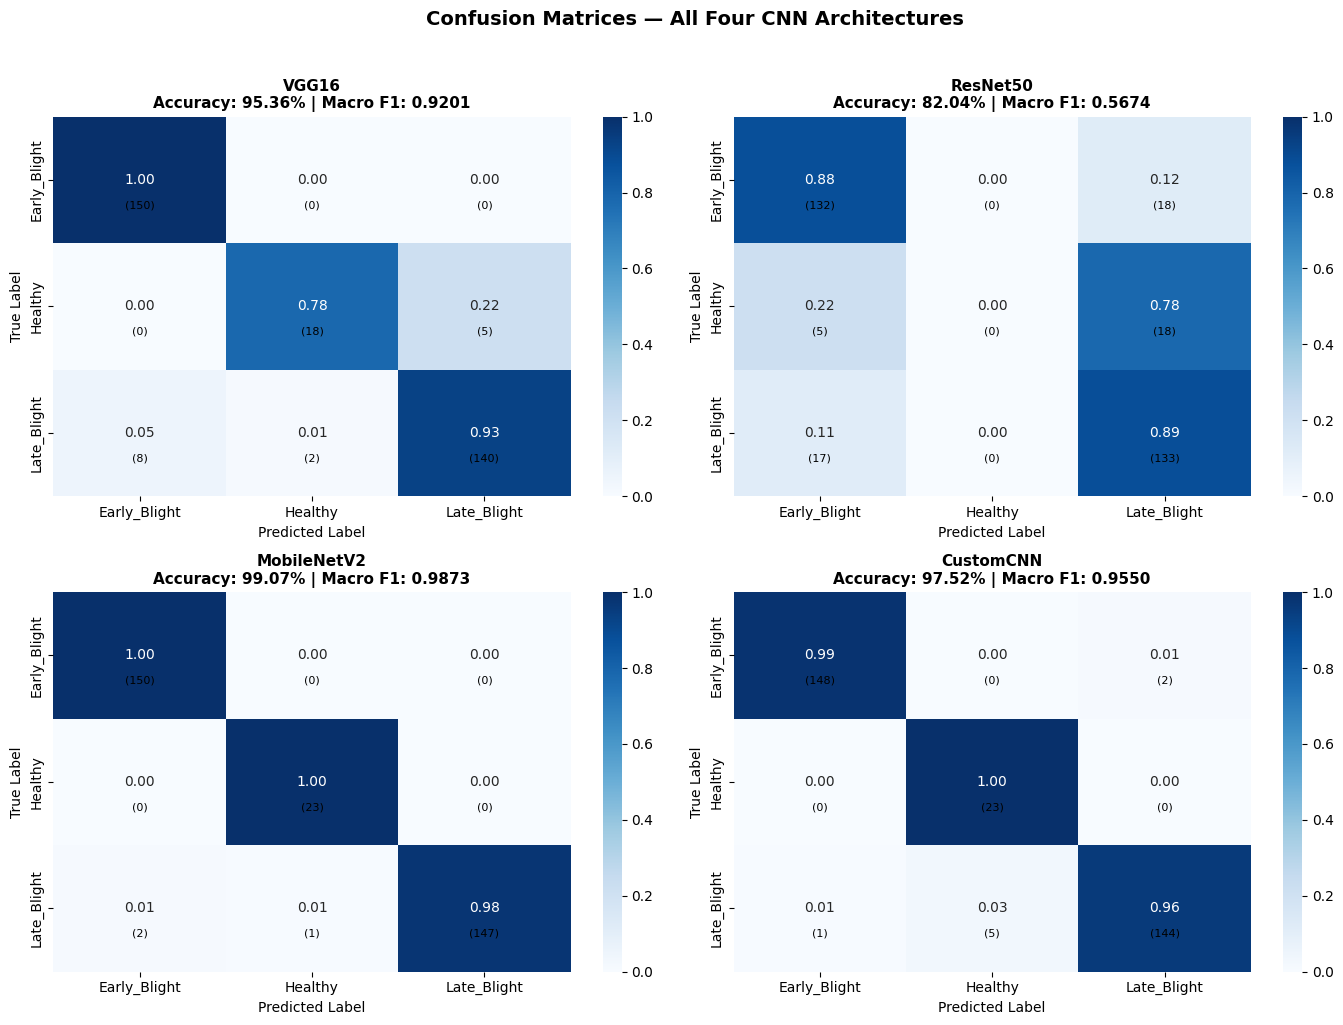

✓ Confusion matrices saved to Drive: /content/drive/MyDrive/LeafNet/results/confusion_matrices_all.png


In [ ]:
#CELL 13: PLOT CONFUSION MATRIX
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

CLASS_NAMES = list(test_data.class_indices.keys())

# Create a 2x2 grid of confusion matrix plots — one per model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # flatten to iterate easily

for idx, (model_name, res) in enumerate(results.items()):
    ax = axes[idx]

    # Normalise confusion matrix to show percentages
    cm = res['cm']
    cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot heatmap
    sns.heatmap(
        cm_normalised,
        annot=True,           # show values inside boxes
        fmt='.2f',            # 2 decimal places
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap='Blues',         # blue colour scale
        ax=ax,
        vmin=0, vmax=1        # scale 0 to 1
    )

    # Also show raw counts in parentheses
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j + 0.5, i + 0.7,
                    f'({cm[i][j]})',
                    ha='center', va='center',
                    fontsize=8, color='black')

    ax.set_title(f'{model_name}\nAccuracy: {res["accuracy"]*100:.2f}% | Macro F1: {res["f1"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrices — All Four CNN Architectures',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save to Drive at high resolution for thesis
save_path = '/content/drive/MyDrive/LeafNet/results/confusion_matrices_all.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print(f"✓ Confusion matrices saved to Drive: {save_path}")

In [ ]:
#CELL 14: TRAINING ACCURACY AND LOSS CURVE
import matplotlib.pyplot as plt

# Note: histories only contains models trained in this session
# If you reloaded from Drive, histories may be empty
# We plot only models that have history available

if not histories:
    print("No training histories available — models were loaded from Drive.")
    print("Training curves can only be plotted during the original training session.")
    print("Check Drive for any saved history files.")
else:
    fig, axes = plt.subplots(len(histories), 2,
                              figsize=(14, 5 * len(histories)))

    # Handle case where only one model has history
    if len(histories) == 1:
        axes = [axes]

    for idx, (model_name, history) in enumerate(histories.items()):
        # ── Accuracy plot ──
        ax1 = axes[idx][0]
        ax1.plot(history.history['accuracy'],
                 label='Training Accuracy', color='blue', linewidth=1.5)
        ax1.plot(history.history['val_accuracy'],
                 label='Validation Accuracy', color='orange',
                 linewidth=1.5, linestyle='--')
        ax1.set_title(f'{model_name} — Accuracy', fontweight='bold')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim([0, 1])

        # ── Loss plot ──
        ax2 = axes[idx][1]
        ax2.plot(history.history['loss'],
                 label='Training Loss', color='blue', linewidth=1.5)
        ax2.plot(history.history['val_loss'],
                 label='Validation Loss', color='orange',
                 linewidth=1.5, linestyle='--')
        ax2.set_title(f'{model_name} — Loss', fontweight='bold')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    plt.suptitle('Training and Validation Curves',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    # Save to Drive
    save_path = '/content/drive/MyDrive/LeafNet/results/training_curves.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print(f"✓ Training curves saved to Drive: {save_path}")

No training histories available — models were loaded from Drive.
Training curves can only be plotted during the original training session.
Check Drive for any saved history files.


In [ ]:
#CELL 15: MEASURE INFERENCE SPEED
import time
import numpy as np

# Get one single test image for timing
# We time how long the model takes to predict one image
test_data.reset()
single_batch = next(iter(test_data))  # get first batch
single_image = single_batch[0][:1]   # take only the first image — shape (1, 224, 224, 3)

print("Measuring inference speed — 50 predictions per model")
print("(Single image, CPU-based timing)")
print()
print(f"{'Model':<15} {'Min (ms)':>10} {'Max (ms)':>10} {'Avg (ms)':>10} {'Std (ms)':>10}")
print("-" * 55)

inference_results = {}

for model_name, model in trained_models.items():
    # Warm-up run — first prediction is always slower
    # due to graph compilation, do not count this
    _ = model.predict(single_image, verbose=0)
    _ = model.predict(single_image, verbose=0)

    # Time 50 predictions
    times = []
    for _ in range(50):
        start = time.perf_counter()           # high precision timer
        model.predict(single_image, verbose=0)
        end = time.perf_counter()
        elapsed_ms = (end - start) * 1000     # convert to milliseconds
        times.append(elapsed_ms)

    # Calculate statistics
    avg_ms = np.mean(times)
    min_ms = np.min(times)
    max_ms = np.max(times)
    std_ms = np.std(times)

    inference_results[model_name] = {
        'avg_ms': avg_ms,
        'min_ms': min_ms,
        'max_ms': max_ms,
        'std_ms': std_ms
    }

    print(f"{model_name:<15} {min_ms:>10.2f} {max_ms:>10.2f} {avg_ms:>10.2f} {std_ms:>10.2f}")

print("-" * 55)

# Identify fastest model
fastest = min(inference_results, key=lambda x: inference_results[x]['avg_ms'])
print(f"\nFastest model: {fastest} ({inference_results[fastest]['avg_ms']:.2f} ms average)")

# Save inference results to Drive
inference_text = "INFERENCE SPEED RESULTS\n" + "="*40 + "\n"
inference_text += f"{'Model':<15} {'Avg ms':>10} {'Min ms':>10} {'Max ms':>10}\n"
inference_text += "-"*40 + "\n"
for model_name, res in inference_results.items():
    inference_text += f"{model_name:<15} {res['avg_ms']:>10.2f} {res['min_ms']:>10.2f} {res['max_ms']:>10.2f}\n"

with open('/content/drive/MyDrive/LeafNet/results/inference_speed.txt', 'w') as f:
    f.write(inference_text)

print(f"\n✓ Inference speed results saved to Drive.")

Measuring inference speed — 50 predictions per model
(Single image, CPU-based timing)

Model             Min (ms)   Max (ms)   Avg (ms)   Std (ms)
-------------------------------------------------------
VGG16               424.07    1692.80     669.16     234.86
ResNet50            174.17     380.83     222.39      58.43
MobileNetV2          77.54     126.62      94.46       9.98
CustomCNN            90.44     220.88     120.98      25.91
-------------------------------------------------------

Fastest model: MobileNetV2 (94.46 ms average)

✓ Inference speed results saved to Drive.


In [2]:
#CELL 16: IMPORT MOBILENETV2 FROM DRIVE TO LOCAL MACHINE
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copy('/content/drive/MyDrive/LeafNet/models/MobileNetV2_finetuned_best.h5',
            '/content/MobileNetV2_final.h5')
print("Copied. Now download via the Colab file browser (left sidebar → folder icon → right-click MobileNetV2_final.h5 → Download).")

Mounted at /content/drive
Copied. Now download via the Colab file browser (left sidebar → folder icon → right-click MobileNetV2_final.h5 → Download).
